# SalesInsight BI — Analyse des ventes avec Python et Machine Learning
Ce projet a pour objectif d’analyser les ventes d’une entreprise fictive à partir d’un fichier Excel.
L’analyse comprend la préparation des données, le calcul des KPI, la visualisation des ventes et un modèle de Machine Learning pour prédire les commandes de forte valeur.

In [5]:
from google.colab import files

uploaded = files.upload()

Saving SalesInsight_BI_Base_Entreprise.xlsx to SalesInsight_BI_Base_Entreprise.xlsx


In [6]:
import pandas as pd

fichier = "SalesInsight_BI_Base_Entreprise.xlsx"

clients = pd.read_excel(fichier, sheet_name="Clients")
produits = pd.read_excel(fichier, sheet_name="Produits")
commandes = pd.read_excel(fichier, sheet_name="Commandes")
lignes_commandes = pd.read_excel(fichier, sheet_name="Lignes_Commandes")

print("Clients :", clients.shape)
print("Produits :", produits.shape)
print("Commandes :", commandes.shape)
print("Lignes commandes :", lignes_commandes.shape)

Clients : (120, 11)
Produits : (50, 9)
Commandes : (420, 11)
Lignes commandes : (965, 9)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [7]:
commandes.head()


,ID_Commande,Date_Commande,ID_Client,ID_Employe,Canal_Vente,Statut_Commande,Mode_Paiement,Frais_Livraison_HT,Total_HT,Total_TTC,Mois
0,CMD00001,2025-10-13,C0025,E010,Téléphone,Livrée,Virement,0.0,748.02,897.62,10-2025
1,CMD00002,2024-07-24,C0017,E009,Téléphone,Livrée,PayPal,4.9,2103.62,2524.34,07-2024
2,CMD00003,2024-12-12,C0103,E002,Marketplace,Annulée,Virement,4.9,1648.02,1977.62,12-2024
3,CMD00004,2025-11-19,C0034,E010,Marketplace,Livrée,PayPal,0.0,559.21,671.05,11-2025
4,CMD00005,2025-12-18,C0039,E007,Web,Livrée,Carte bancaire,7.9,821.79,986.15,12-2025


In [8]:
lignes_commandes.head()

,ID_Ligne,ID_Commande,ID_Produit,Quantité,Prix_Unitaire_HT,Remise_%,CA_HT,TVA,CA_TTC
0,L000001,CMD00001,P0042,1,70.80,0.05,67.26,13.45,80.71
1,L000002,CMD00001,P0003,2,216.77,0.15,368.51,73.70,442.21
2,L000003,CMD00001,P0009,1,120.37,0.00,120.37,24.07,144.44
3,L000004,CMD00001,P0021,3,63.96,0.00,191.88,38.38,230.26
4,L000005,CMD00002,P0031,8,262.34,0.00,2098.72,419.74,2518.46


In [9]:
# Vérifier la taille des tables
print("Clients :", clients.shape)
print("Produits :", produits.shape)
print("Commandes :", commandes.shape)
print("Lignes commandes :", lignes_commandes.shape)

# Vérifier les colonnes
print("\nColonnes Commandes :")
print(commandes.columns)

print("\nColonnes Lignes_Commandes :")
print(lignes_commandes.columns)

Clients : (120, 11)
Produits : (50, 9)
Commandes : (420, 11)
Lignes commandes : (965, 9)

Colonnes Commandes :
Index(['ID_Commande', 'Date_Commande', 'ID_Client', 'ID_Employe',
       'Canal_Vente', 'Statut_Commande', 'Mode_Paiement', 'Frais_Livraison_HT',
       'Total_HT', 'Total_TTC', 'Mois'],
      dtype='object')

Colonnes Lignes_Commandes :
Index(['ID_Ligne', 'ID_Commande', 'ID_Produit', 'Quantité', 'Prix_Unitaire_HT',
       'Remise_%', 'CA_HT', 'TVA', 'CA_TTC'],
      dtype='object')


In [10]:
# Vérifier les valeurs manquantes
print("Valeurs manquantes - Commandes")
print(commandes.isnull().sum())

print("\nValeurs manquantes - Lignes_Commandes")
print(lignes_commandes.isnull().sum())

Valeurs manquantes - Commandes
ID_Commande           0
Date_Commande         0
ID_Client             0
ID_Employe            0
Canal_Vente           0
Statut_Commande       0
Mode_Paiement         0
Frais_Livraison_HT    0
Total_HT              0
Total_TTC             0
Mois                  0
dtype: int64

Valeurs manquantes - Lignes_Commandes
ID_Ligne            0
ID_Commande         0
ID_Produit          0
Quantité            0
Prix_Unitaire_HT    0
Remise_%            0
CA_HT               0
TVA                 0
CA_TTC              0
dtype: int64


In [11]:
# Vérifier les types de données
print("Types Commandes")
print(commandes.dtypes)

print("\nTypes Lignes_Commandes")
print(lignes_commandes.dtypes)

Types Commandes
ID_Commande                   object
Date_Commande         datetime64[ns]
ID_Client                     object
ID_Employe                    object
Canal_Vente                   object
Statut_Commande               object
Mode_Paiement                 object
Frais_Livraison_HT           float64
Total_HT                     float64
Total_TTC                    float64
Mois                          object
dtype: object

Types Lignes_Commandes
ID_Ligne             object
ID_Commande          object
ID_Produit           object
Quantité              int64
Prix_Unitaire_HT    float64
Remise_%            float64
CA_HT               float64
TVA                 float64
CA_TTC              float64
dtype: object


In [12]:
# Fusionner lignes_commandes avec commandes
ventes = lignes_commandes.merge(
    commandes[["ID_Commande", "Date_Commande", "Mois", "ID_Client", "Canal_Vente", "Statut_Commande"]],
    on="ID_Commande",
    how="left"
)

# Fusionner avec produits
ventes = ventes.merge(
    produits[["ID_Produit", "Nom_Produit", "Catégorie"]],
    on="ID_Produit",
    how="left"
)

# Afficher les premières lignes
ventes.head()

,ID_Ligne,ID_Commande,ID_Produit,Quantité,Prix_Unitaire_HT,Remise_%,CA_HT,TVA,CA_TTC,Date_Commande,Mois,ID_Client,Canal_Vente,Statut_Commande,Nom_Produit,Catégorie
0,L000001,CMD00001,P0042,1,70.80,0.05,67.26,13.45,80.71,2025-10-13,10-2025,C0025,Téléphone,Livrée,Casque audio V2,Accessoires
1,L000002,CMD00001,P0003,2,216.77,0.15,368.51,73.70,442.21,2025-10-13,10-2025,C0025,Téléphone,Livrée,Écran 27 pouces,Informatique
2,L000003,CMD00001,P0009,1,120.37,0.00,120.37,24.07,144.44,2025-10-13,10-2025,C0025,Téléphone,Livrée,Station d'accueil USB-C,Informatique
3,L000004,CMD00001,P0021,3,63.96,0.00,191.88,38.38,230.26,2025-10-13,10-2025,C0025,Téléphone,Livrée,Licence CRM,Logiciel
4,L000005,CMD00002,P0031,8,262.34,0.00,2098.72,419.74,2518.46,2024-07-24,07-2024,C0017,Téléphone,Livrée,Formation Excel,Formation


In [13]:
print("Taille de la table ventes :", ventes.shape)
print("\nValeurs manquantes après fusion :")
print(ventes.isnull().sum())

Taille de la table ventes : (965, 16)

Valeurs manquantes après fusion :
ID_Ligne            0
ID_Commande         0
ID_Produit          0
Quantité            0
Prix_Unitaire_HT    0
Remise_%            0
CA_HT               0
TVA                 0
CA_TTC              0
Date_Commande       0
Mois                0
ID_Client           0
Canal_Vente         0
Statut_Commande     0
Nom_Produit         0
Catégorie           0
dtype: int64


In [14]:
# KPI principaux

ca_total = ventes["CA_HT"].sum()
nombre_commandes = ventes["ID_Commande"].nunique()
nombre_clients = ventes["ID_Client"].nunique()
quantite_vendue = ventes["Quantité"].sum()
panier_moyen = ca_total / nombre_commandes

print("Chiffre d'affaires HT total :", round(ca_total, 2), "€")
print("Nombre de commandes :", nombre_commandes)
print("Nombre de clients :", nombre_clients)
print("Quantité totale vendue :", quantite_vendue)
print("Panier moyen HT :", round(panier_moyen, 2), "€")

Chiffre d'affaires HT total : 368992.73 €
Nombre de commandes : 420
Nombre de clients : 119
Quantité totale vendue : 2097
Panier moyen HT : 878.55 €


In [15]:
# Chiffre d'affaires HT par mois

ca_par_mois = ventes.groupby("Mois")["CA_HT"].sum().reset_index()

# Trier du plus grand au plus petit
ca_par_mois = ca_par_mois.sort_values(by="CA_HT", ascending=False)

ca_par_mois.head(10)

,Mois,CA_HT
17,09-2025,27307.06
9,05-2025,22347.78
1,01-2025,20977.42
10,06-2024,19627.83
19,10-2025,19596.86
2,02-2024,19428.38
20,11-2024,19410.94
22,12-2024,18594.92
7,04-2025,17034.70
5,03-2025,16658.92


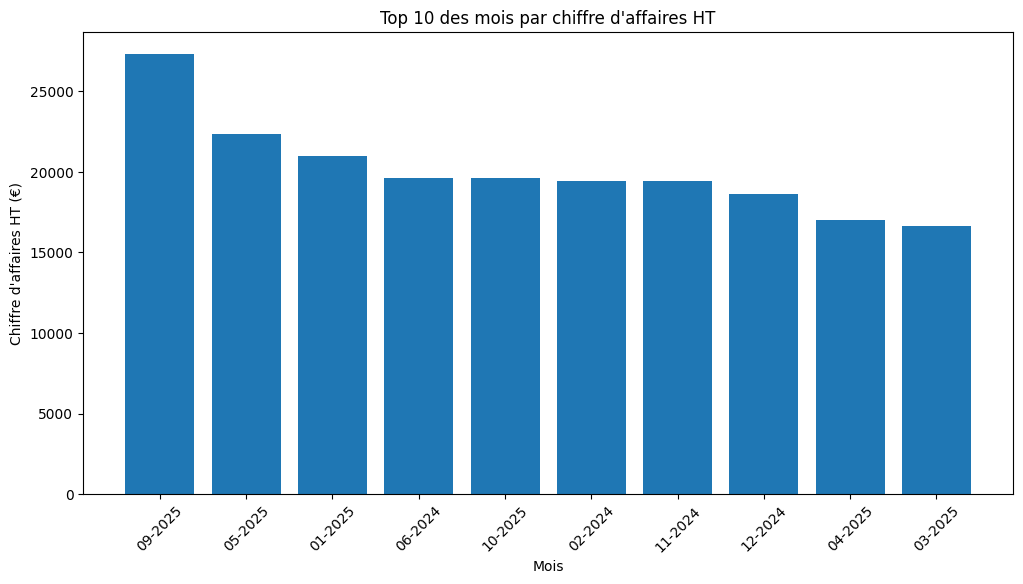

In [16]:
import matplotlib.pyplot as plt

top_mois = ca_par_mois.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_mois["Mois"], top_mois["CA_HT"])
plt.title("Top 10 des mois par chiffre d'affaires HT")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires HT (€)")
plt.xticks(rotation=45)
plt.show()

In [17]:
# Chiffre d'affaires HT par canal de vente

ca_par_canal = ventes.groupby("Canal_Vente")["CA_HT"].sum().reset_index()
ca_par_canal = ca_par_canal.sort_values(by="CA_HT", ascending=False)

ca_par_canal

,Canal_Vente,CA_HT
2,Téléphone,98734.07
0,Magasin,96940.19
3,Web,90233.96
1,Marketplace,83084.51


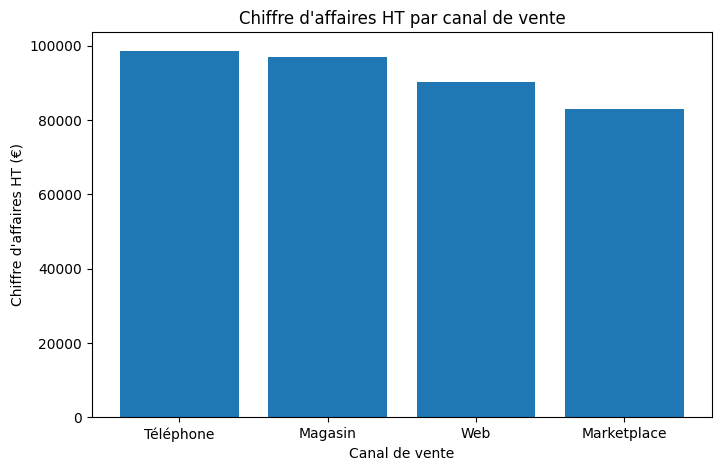

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(ca_par_canal["Canal_Vente"], ca_par_canal["CA_HT"])
plt.title("Chiffre d'affaires HT par canal de vente")
plt.xlabel("Canal de vente")
plt.ylabel("Chiffre d'affaires HT (€)")
plt.show()

In [19]:
ca_par_mois.head(10)
ca_par_canal

,Canal_Vente,CA_HT
2,Téléphone,98734.07
0,Magasin,96940.19
3,Web,90233.96
1,Marketplace,83084.51


In [20]:
# Chiffre d'affaires HT par catégorie de produit

ca_par_categorie = ventes.groupby("Catégorie")["CA_HT"].sum().reset_index()
ca_par_categorie = ca_par_categorie.sort_values(by="CA_HT", ascending=False)

ca_par_categorie

,Catégorie,CA_HT
2,Formation,152930.78
3,Informatique,117983.56
1,Bureau,52460.98
0,Accessoires,23135.49
4,Logiciel,22481.92


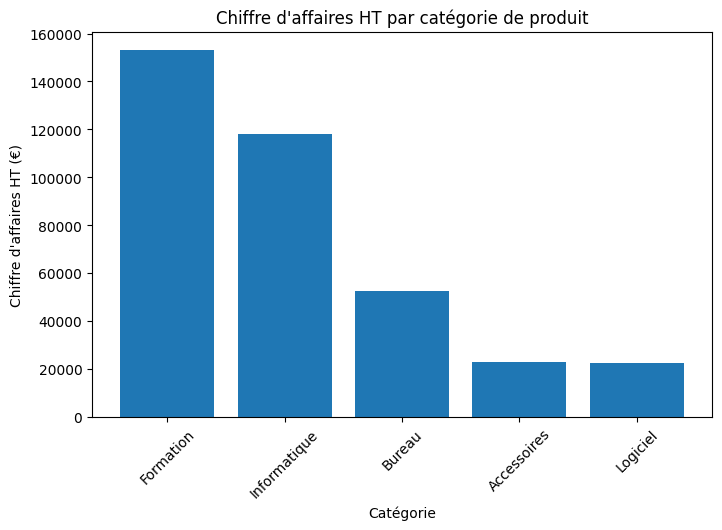

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(ca_par_categorie["Catégorie"], ca_par_categorie["CA_HT"])
plt.title("Chiffre d'affaires HT par catégorie de produit")
plt.xlabel("Catégorie")
plt.ylabel("Chiffre d'affaires HT (€)")
plt.xticks(rotation=45)
plt.show()

In [22]:
# Top 10 produits par chiffre d'affaires HT

top_produits = ventes.groupby("Nom_Produit")["CA_HT"].sum().reset_index()
top_produits = top_produits.sort_values(by="CA_HT", ascending=False).head(10)

top_produits

,Nom_Produit,CA_HT
30,Laptop Pro 14,51208.91
31,Laptop Pro 14 V2,32223.25
25,Formation Python V2,26801.89
22,Formation Power BI,20566.95
5,Atelier SQL V2,18097.66
18,Coaching Data,17743.01
7,Bureau réglable V2,14252.91
23,Formation Power BI V2,14041.90
19,Coaching Data V2,12434.50
6,Bureau réglable,12054.77


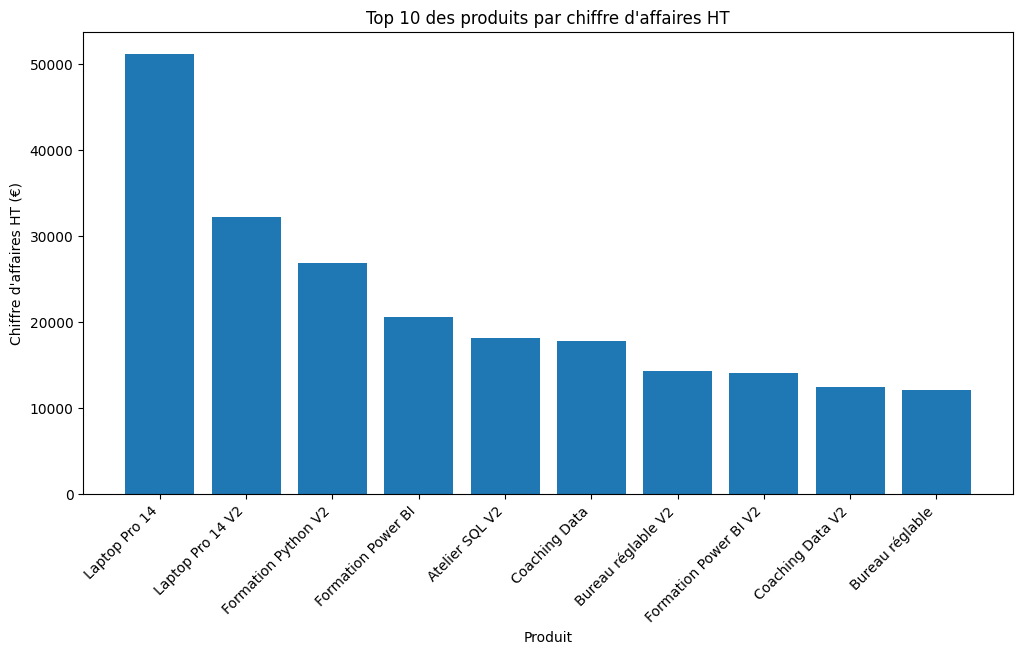

In [25]:
plt.figure(figsize=(12, 6))
plt.bar(top_produits["Nom_Produit"], top_produits["CA_HT"])
plt.title("Top 10 des produits par chiffre d'affaires HT")
plt.xlabel("Produit")
plt.ylabel("Chiffre d'affaires HT (€)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [27]:
print(clients.columns)
clients.head()

Index(['ID_Client', 'Nom', 'Prénom', 'Email', 'Ville', 'Région', 'Pays',
       'Segment', 'Date_Inscription', 'Canal_Acquisition', 'Actif'],
      dtype='object')


,ID_Client,Nom,Prénom,Email,Ville,Région,Pays,Segment,Date_Inscription,Canal_Acquisition,Actif
0,C0001,Thomas,Linh,linh.thomas1@example.com,Toulouse,Occitanie,France,PME,2023-09-08,Réseaux sociaux,Oui
1,C0002,Tran,Hugo,hugo.tran2@example.com,Genève,Genève,Suisse,PME,2023-03-31,Salon professionnel,Oui
2,C0003,Dubois,Emma,emma.dubois3@example.com,Bordeaux,Nouvelle-Aquitaine,France,Particulier,2024-09-08,SEO,Oui
3,C0004,Nguyen,Tú,tú.nguyen4@example.com,Genève,Genève,Suisse,Particulier,2023-08-14,Parrainage,Oui
4,C0005,Martin,Bao,bao.martin5@example.com,Lyon,Auvergne-Rhône-Alpes,France,Particulier,2023-12-15,Publicité,Oui


In [28]:
# Voir les colonnes disponibles dans la table Clients
clients.columns.tolist()

['ID_Client',
 'Nom',
 'Prénom',
 'Email',
 'Ville',
 'Région',
 'Pays',
 'Segment',
 'Date_Inscription',
 'Canal_Acquisition',
 'Actif']

In [29]:
# Fusionner ventes avec toute la table clients
ventes_clients = ventes.merge(
    clients,
    on="ID_Client",
    how="left"
)

# Vérifier les colonnes après fusion
ventes_clients.columns.tolist()

['ID_Ligne',
 'ID_Commande',
 'ID_Produit',
 'Quantité',
 'Prix_Unitaire_HT',
 'Remise_%',
 'CA_HT',
 'TVA',
 'CA_TTC',
 'Date_Commande',
 'Mois',
 'ID_Client',
 'Canal_Vente',
 'Statut_Commande',
 'Nom_Produit',
 'Catégorie',
 'Nom',
 'Prénom',
 'Email',
 'Ville',
 'Région',
 'Pays',
 'Segment',
 'Date_Inscription',
 'Canal_Acquisition',
 'Actif']

In [30]:
ventes_clients.head()

,ID_Ligne,ID_Commande,ID_Produit,Quantité,Prix_Unitaire_HT,Remise_%,CA_HT,TVA,CA_TTC,Date_Commande,...,Nom,Prénom,Email,Ville,Région,Pays,Segment,Date_Inscription,Canal_Acquisition,Actif
0,L000001,CMD00001,P0042,1,70.80,0.05,67.26,13.45,80.71,2025-10-13,...,Martin,Raphaël,raphaël.martin25@example.com,Paris,Île-de-France,France,PME,2023-11-11,Réseaux sociaux,Oui
1,L000002,CMD00001,P0003,2,216.77,0.15,368.51,73.70,442.21,2025-10-13,...,Martin,Raphaël,raphaël.martin25@example.com,Paris,Île-de-France,France,PME,2023-11-11,Réseaux sociaux,Oui
2,L000003,CMD00001,P0009,1,120.37,0.00,120.37,24.07,144.44,2025-10-13,...,Martin,Raphaël,raphaël.martin25@example.com,Paris,Île-de-France,France,PME,2023-11-11,Réseaux sociaux,Oui
3,L000004,CMD00001,P0021,3,63.96,0.00,191.88,38.38,230.26,2025-10-13,...,Martin,Raphaël,raphaël.martin25@example.com,Paris,Île-de-France,France,PME,2023-11-11,Réseaux sociaux,Oui
4,L000005,CMD00002,P0031,8,262.34,0.00,2098.72,419.74,2518.46,2024-07-24,...,Leroy,Tom,tom.leroy17@example.com,Genève,Genève,Suisse,Particulier,2024-08-20,Parrainage,Oui


In [31]:
top_clients = ventes_clients.groupby("Nom")["CA_HT"].sum().reset_index()
top_clients = top_clients.sort_values(by="CA_HT", ascending=False).head(10)

top_clients

,Nom,CA_HT
24,Vincent,29618.45
20,Roux,25377.51
16,Petit,24745.57
0,Bernard,23492.11
4,Dubois,22247.17
5,Durand,21160.49
2,Dang,21028.48
7,Garcia,18159.49
11,Leroy,17641.07
19,Robert,16313.64


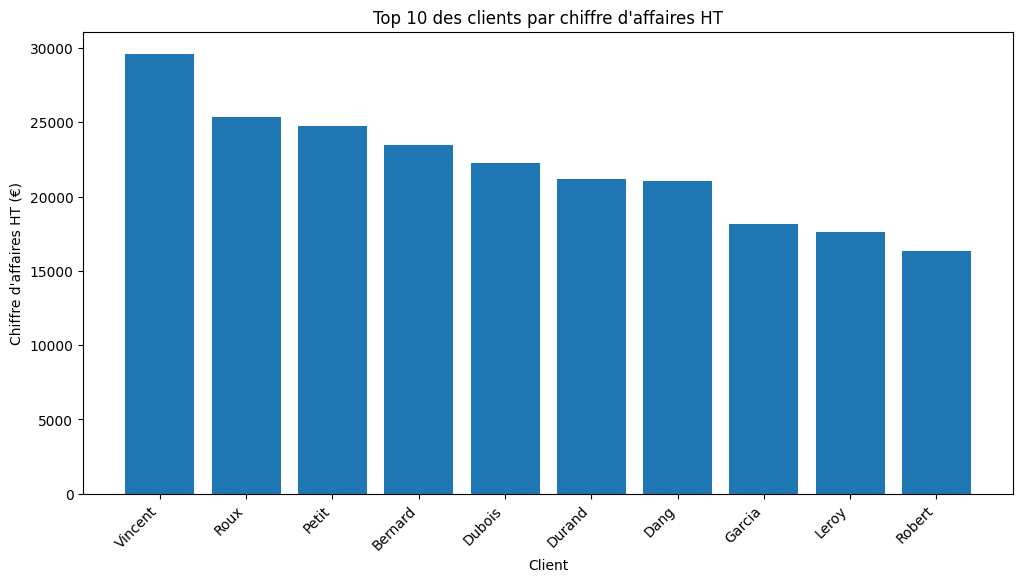

In [32]:
plt.figure(figsize=(12, 6))
plt.bar(top_clients["Nom"], top_clients["CA_HT"])
plt.title("Top 10 des clients par chiffre d'affaires HT")
plt.xlabel("Client")
plt.ylabel("Chiffre d'affaires HT (€)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [33]:
meilleur_mois = ca_par_mois.iloc[0]
meilleur_canal = ca_par_canal.iloc[0]
meilleure_categorie = ca_par_categorie.iloc[0]
meilleur_produit = top_produits.iloc[0]
meilleur_client = top_clients.iloc[0]

print("===== SYNTHÈSE DE L'ANALYSE =====")
print(f"Chiffre d'affaires HT total : {ca_total:,.2f} €")
print(f"Nombre de commandes : {nombre_commandes}")
print(f"Nombre de clients : {nombre_clients}")
print(f"Panier moyen HT : {panier_moyen:,.2f} €")
print()
print(f"Meilleur mois : {meilleur_mois['Mois']} avec {meilleur_mois['CA_HT']:,.2f} €")
print(f"Meilleur canal : {meilleur_canal['Canal_Vente']} avec {meilleur_canal['CA_HT']:,.2f} €")
print(f"Meilleure catégorie : {meilleure_categorie['Catégorie']} avec {meilleure_categorie['CA_HT']:,.2f} €")
print(f"Meilleur produit : {meilleur_produit['Nom_Produit']} avec {meilleur_produit['CA_HT']:,.2f} €")
print(f"Meilleur client : {meilleur_client['Nom']} avec {meilleur_client['CA_HT']:,.2f} €")

===== SYNTHÈSE DE L'ANALYSE =====
Chiffre d'affaires HT total : 368,992.73 €
Nombre de commandes : 420
Nombre de clients : 119
Panier moyen HT : 878.55 €

Meilleur mois : 09-2025 avec 27,307.06 €
Meilleur canal : Téléphone avec 98,734.07 €
Meilleure catégorie : Formation avec 152,930.78 €
Meilleur produit : Laptop Pro 14 avec 51,208.91 €
Meilleur client : Vincent avec 29,618.45 €


In [34]:
# Créer une table au niveau commande

commandes_ml = ventes.groupby("ID_Commande").agg({
    "CA_HT": "sum",
    "Quantité": "sum",
    "Remise_%": "mean",
    "ID_Produit": "nunique",
    "Canal_Vente": "first",
    "Statut_Commande": "first",
    "Mois": "first",
    "ID_Client": "first"
}).reset_index()

commandes_ml = commandes_ml.rename(columns={
    "CA_HT": "CA_HT_Commande",
    "Quantité": "Quantite_Totale",
    "Remise_%": "Remise_Moyenne",
    "ID_Produit": "Nombre_Produits"
})

commandes_ml.head()

,ID_Commande,CA_HT_Commande,Quantite_Totale,Remise_Moyenne,Nombre_Produits,Canal_Vente,Statut_Commande,Mois,ID_Client
0,CMD00001,748.02,7,0.0500,4,Téléphone,Livrée,10-2025,C0025
1,CMD00002,2098.72,8,0.0000,1,Téléphone,Livrée,07-2024,C0017
2,CMD00003,1643.12,5,0.0625,4,Marketplace,Annulée,12-2024,C0103
3,CMD00004,559.21,6,0.0500,3,Marketplace,Livrée,11-2025,C0034
4,CMD00005,813.89,9,0.0900,5,Web,Livrée,12-2025,C0039


In [35]:
# Créer la cible : commande forte valeur

seuil = commandes_ml["CA_HT_Commande"].median()

commandes_ml["Forte_Valeur"] = commandes_ml["CA_HT_Commande"].apply(
    lambda x: 1 if x > seuil else 0
)

print("Seuil de forte valeur :", round(seuil, 2), "€")
print(commandes_ml["Forte_Valeur"].value_counts())

Seuil de forte valeur : 510.17 €
Forte_Valeur
1    210
0    210
Name: count, dtype: int64


In [36]:
# Sélection des variables explicatives

X = commandes_ml[[
    "Quantite_Totale",
    "Remise_Moyenne",
    "Nombre_Produits",
    "Canal_Vente",
    "Statut_Commande"
]]

y = commandes_ml["Forte_Valeur"]

# Transformer les variables texte en variables numériques
X = pd.get_dummies(X, columns=["Canal_Vente", "Statut_Commande"], drop_first=True)

X.head()

,Quantite_Totale,Remise_Moyenne,Nombre_Produits,Canal_Vente_Marketplace,Canal_Vente_Téléphone,Canal_Vente_Web,Statut_Commande_En cours,Statut_Commande_Livrée,Statut_Commande_Retournée
0,7,0.0500,4,False,True,False,False,True,False
1,8,0.0000,1,False,True,False,False,True,False
2,5,0.0625,4,True,False,False,False,False,False
3,6,0.0500,3,True,False,False,False,True,False
4,9,0.0900,5,False,False,True,False,True,False


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Séparer les données en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Créer le modèle
modele = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entraîner le modèle
modele.fit(X_train, y_train)

# Faire des prédictions
y_pred = modele.predict(X_test)

# Évaluer le modèle
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 3))
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Accuracy : 0.714

Matrice de confusion :
[[28 14]
 [10 32]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.74      0.67      0.70        42
           1       0.70      0.76      0.73        42

    accuracy                           0.71        84
   macro avg       0.72      0.71      0.71        84
weighted avg       0.72      0.71      0.71        84



Un modèle de classification Random Forest a été entraîné afin de prédire si une commande est de forte valeur. Le seuil de forte valeur a été défini à partir de la médiane du chiffre d’affaires HT par commande, soit 510,17 €. Le modèle obtient une accuracy de 71,4 %, avec un recall de 76 % pour les commandes de forte valeur.

In [38]:
# Importance des variables du modèle

importances = pd.DataFrame({
    "Variable": X.columns,
    "Importance": modele.feature_importances_
})

importances = importances.sort_values(by="Importance", ascending=False)

importances

,Variable,Importance
0,Quantite_Totale,0.401598
1,Remise_Moyenne,0.229302
2,Nombre_Produits,0.220020
5,Canal_Vente_Web,0.047975
4,Canal_Vente_Téléphone,0.035965
3,Canal_Vente_Marketplace,0.029932
7,Statut_Commande_Livrée,0.016722
8,Statut_Commande_Retournée,0.009973
6,Statut_Commande_En cours,0.008513


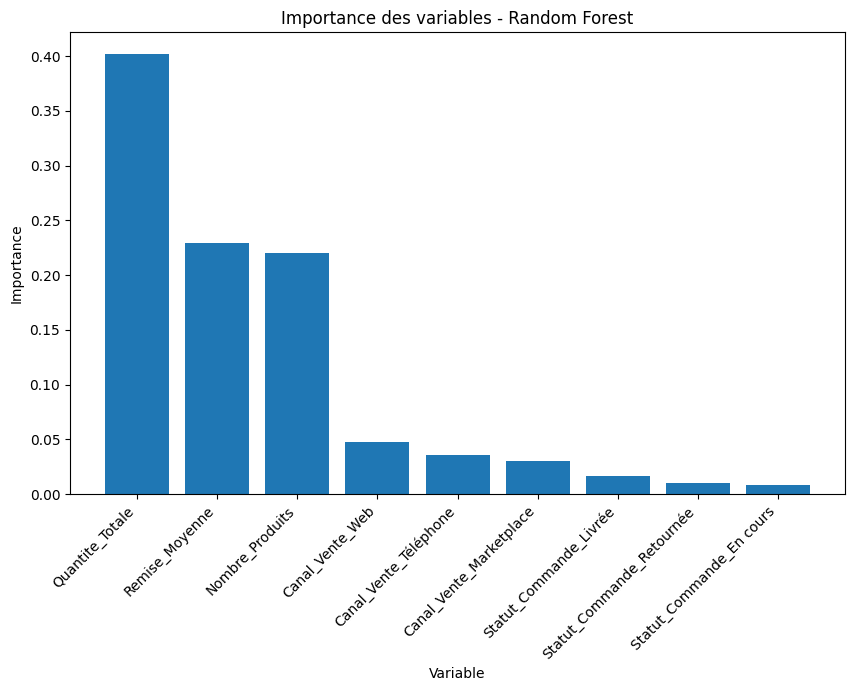

In [39]:
plt.figure(figsize=(10, 6))
plt.bar(importances["Variable"], importances["Importance"])
plt.title("Importance des variables - Random Forest")
plt.xlabel("Variable")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

L’analyse montre que le chiffre d’affaires HT total est de 368 992,73 € pour 420 commandes et 119 clients.
Le panier moyen HT est de 878,55 €. Le mois le plus performant est septembre 2025 avec 27 307,06 €.
Le canal le plus rentable est Téléphone avec 98 734,07 €. La catégorie Formation est la plus performante avec 152 930,78 €.

Un modèle Random Forest a été entraîné pour prédire les commandes de forte valeur.
Le seuil de forte valeur a été fixé à 510,17 €, correspondant à la médiane du chiffre d’affaires HT par commande.
Le modèle obtient une accuracy de 71,4 %, avec un recall de 76 % pour les commandes de forte valeur.

Ce projet montre ma capacité à analyser des données d’entreprise, créer des KPI, visualiser des résultats et appliquer un premier modèle de Machine Learning.

## Analyse SQL

In [40]:
import sqlite3

# Créer une base de données SQLite
conn = sqlite3.connect("salesinsight_bi.db")

# Envoyer les DataFrames vers la base SQL
clients.to_sql("clients", conn, if_exists="replace", index=False)
produits.to_sql("produits", conn, if_exists="replace", index=False)
commandes.to_sql("commandes", conn, if_exists="replace", index=False)
lignes_commandes.to_sql("lignes_commandes", conn, if_exists="replace", index=False)

print("Base de données SQL créée avec succès.")

Base de données SQL créée avec succès.


In [41]:
requete = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql_query(requete, conn)

,name
0,clients
1,produits
2,commandes
3,lignes_commandes


In [42]:
requete = """
SELECT
    ROUND(SUM(CA_HT), 2) AS chiffre_affaires_ht_total
FROM lignes_commandes;
"""

pd.read_sql_query(requete, conn)

,chiffre_affaires_ht_total
0,368992.73


In [43]:
requete = """
SELECT
    COUNT(DISTINCT ID_Commande) AS nombre_commandes
FROM lignes_commandes;
"""

pd.read_sql_query(requete, conn)

,nombre_commandes
0,420


In [44]:
requete = """
SELECT
    p.Nom_Produit,
    p.Catégorie,
    ROUND(SUM(l.CA_HT), 2) AS chiffre_affaires_ht
FROM lignes_commandes l
JOIN produits p
    ON l.ID_Produit = p.ID_Produit
GROUP BY p.Nom_Produit, p.Catégorie
ORDER BY chiffre_affaires_ht DESC
LIMIT 10;
"""

pd.read_sql_query(requete, conn)

,Nom_Produit,Catégorie,chiffre_affaires_ht
0,Laptop Pro 14,Informatique,51208.91
1,Laptop Pro 14 V2,Informatique,32223.25
2,Formation Python V2,Formation,26801.89
3,Formation Power BI,Formation,20566.95
4,Atelier SQL V2,Formation,18097.66
5,Coaching Data,Formation,17743.01
6,Bureau réglable V2,Bureau,14252.91
7,Formation Power BI V2,Formation,14041.90
8,Coaching Data V2,Formation,12434.50
9,Bureau réglable,Bureau,12054.77


In [45]:
requete = """
SELECT
    c.Canal_Vente,
    ROUND(SUM(l.CA_HT), 2) AS chiffre_affaires_ht
FROM lignes_commandes l
JOIN commandes c
    ON l.ID_Commande = c.ID_Commande
GROUP BY c.Canal_Vente
ORDER BY chiffre_affaires_ht DESC;
"""

pd.read_sql_query(requete, conn)

,Canal_Vente,chiffre_affaires_ht
0,Téléphone,98734.07
1,Magasin,96940.19
2,Web,90233.96
3,Marketplace,83084.51


In [46]:
requete = """
SELECT
    cl.Nom,
    ROUND(SUM(l.CA_HT), 2) AS chiffre_affaires_ht
FROM lignes_commandes l
JOIN commandes c
    ON l.ID_Commande = c.ID_Commande
JOIN clients cl
    ON c.ID_Client = cl.ID_Client
GROUP BY cl.Nom
ORDER BY chiffre_affaires_ht DESC
LIMIT 10;
"""

pd.read_sql_query(requete, conn)

,Nom,chiffre_affaires_ht
0,Vincent,29618.45
1,Roux,25377.51
2,Petit,24745.57
3,Bernard,23492.11
4,Dubois,22247.17
5,Durand,21160.49
6,Dang,21028.48
7,Garcia,18159.49
8,Leroy,17641.07
9,Robert,16313.64


In [47]:
requete = """
SELECT
    p.Catégorie,
    ROUND(SUM(l.CA_HT), 2) AS chiffre_affaires_ht
FROM lignes_commandes l
JOIN produits p
    ON l.ID_Produit = p.ID_Produit
GROUP BY p.Catégorie
ORDER BY chiffre_affaires_ht DESC;
"""

pd.read_sql_query(requete, conn)

,Catégorie,chiffre_affaires_ht
0,Formation,152930.78
1,Informatique,117983.56
2,Bureau,52460.98
3,Accessoires,23135.49
4,Logiciel,22481.92
